In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import cv2
import math

def compute_errors(original, images):
    errors = [np.abs(original - image).mean() for image in images]
    #print(errors)
    relative_errors = [(error / errors[0]) for error in errors]

    return relative_errors

In [24]:
# extend the image for gaussian filtering
# 2 more pixels on each side, since the kernel is 5*5
# extend similar to cv2.REFLECT_101 for Neumann condition
def extend_image(image):
  height = image.shape[0]
  width = image.shape[1]
  extended_image = np.zeros((height+4, width+4))

  # the four sides
  extended_image[2:height+2, 2:width+2] = image
  extended_image[2:height+2, 0] = image[0:height, 1]
  extended_image[2:height+2, 1] = image[0:height, 0]
  extended_image[0, 2:width+2] = image[1, 0:width]
  extended_image[1, 2:width+2] = image[0, 0:width]
  extended_image[2:height+2, width+2] = image[0:height, width-1]
  extended_image[2:height+2, width+3] = image[0:height, width-2]
  extended_image[height+2, 2:width+2] = image[height-1, 0:width]
  extended_image[height+3, 2:width+2] = image[height-2, 0:width]

  # the four corners
  # top left corner
  extended_image[0:2, 0:2] = image[0:2, 0:2]
  extended_image[0,0] = image[1,1]
  extended_image[1,1] = image[0,0]

  # top right corner
  extended_image[0:2, width+2:] = image[0:2, width-2:]
  extended_image[0, width+3] = image[1, width-2]
  extended_image[1, width+2] = image[0, width-1]

  # bottom left corner
  extended_image[height+2:, 0:2] = image[height-2:, 0:2]
  extended_image[height+2, 1] = image[height-1, 0]
  extended_image[height+3, 0] = image[height-2, 1]

  # botton right corner
  extended_image[height+2:, width+2:] = image[height-2:, width-2:]
  extended_image[height+2, width+2] = image[height-1, width-1]
  extended_image[height+3, width+3] = image[height-2, width-2]

  return extended_image

In [25]:
def convolution(kernel, extended_image):
  extended_height = extended_image.shape[0]
  extended_width = extended_image.shape[1]

  convolved_image = np.zeros((extended_height, extended_width))
  for i in range(2, extended_height-2):
    for j in range(2, extended_width-2):
      sum = 0
      for a in range(0, 5):
        for b in range(0, 5):
          sum += kernel[a, b] * extended_image[i - (a-2),j - (b-2)]
      convolved_image[i,j] = sum

  back_to_original_size = convolved_image[2:extended_height-2, 2:extended_width-2]
  return back_to_original_size

In [26]:
# Task1: filtering
# self implemented gaussian filter
def gaussian_filter(image, iterations = 32):
    image_to_blur = image.copy()
    standard_deviation = 0.5
    # size = 2 * math.ceil(3*standard_deviation) + 1 = 5, so we have a 5*5 kernel
    # the gaussian function is K(a,b) = 1 / (2 * pi * standard_deviation^2) * exp(-(a^2 + b^2) / (2 * standard_deviation^2))
    # first calculate the (a^2 + b^2)
    kernel = [[8,5,4,5,8],[5,2,1,2,5],[4,1,0,1,4],[5,2,1,2,5],[8,5,4,5,8]]
    kernel = np.array(kernel)
    kernel = -kernel/(2*standard_deviation**2)
    kernel = np.exp(kernel)
    kernel = kernel / np.sum(kernel)

    images = [image.copy()]

    for i in range(iterations):
        padded_image = extend_image(image_to_blur)
        image_to_blur = convolution(kernel, padded_image)
        images.append(image_to_blur.copy())

    return images

In [27]:
# Task1: filtering
# uses the liberay as reference
def gaussian_filter_reference(image, iterations = 32):
    image_to_blur = image.copy()
    standard_deviation = 0.5
    size = 2 * math.ceil(3*standard_deviation) + 1

    images = [image.copy()]

    for i in range(iterations):
        # I use cv2.GaussianBlur() as filter
        # standard_deviation and size are formalized as described in the exercise sheet
        # normalization after defining filter required in the exercise sheet should be done well by cv2.GaussianBlur()
        # borderType = cv2.BORDER_REFLECT_101 is chosen to simulate Neumann boundary conditions, where the gradient at the border of the image is zero

        image_to_blur = cv2.GaussianBlur(image_to_blur, (size, size), standard_deviation, borderType = cv2.BORDER_REFLECT_101)
        images.append(image_to_blur.copy())

    return images


In [28]:
# plot the 8th, 16th, 24th and 32th filtered images
# plot the error evolution of using gaussian filter
def show_filter(I_orig, I_n, iterations = 32):
    # apply gaussian filter
    images_filter = gaussian_filter(I_n, iterations)

    for i in [8, 16, 24, 32]:
      #Image.fromarray((np.clip(images_filter[i]*255.0, 0, 255)).astype(np.uint8)).show()
      plt.figure(figsize=(40, 20))
      plt.subplot(1, 4, (int)(i/8))
      plt.imshow(np.clip(images_filter[i]*255.0, 0, 255), cmap='gray')
      plt.title('Filtered '+str(i)+' times')
    plt.show()

    iter_indices = np.arange(0, iterations + 1, 1)
    error_filter = compute_errors(I_orig, images_filter)
    plt.plot(iter_indices, error_filter)
    plt.show()


In [29]:
# plot the 8th, 16th, 24th and 32th filtered images using the cv.GaussianBlur()
# plot the error evolution of using gaussian filter
def show_filter_reference(I_orig, I_n, iterations = 32):
    # apply gaussian filter
    images_filter = gaussian_filter_reference(I_n, iterations)

    for i in [8, 16, 24, 32]:
      #Image.fromarray((np.clip(images_filter[i]*255.0, 0, 255)).astype(np.uint8)).show()
      plt.figure(figsize=(40, 20))
      plt.subplot(1, 4, (int)(i/8))
      plt.imshow(np.clip(images_filter[i]*255.0, 0, 255), cmap='gray')
      plt.title('Filtered '+str(i)+' times by cv.GaussianBlur()')
    plt.show()

    iter_indices = np.arange(0, iterations + 1, 1)
    error_filter = compute_errors(I_orig, images_filter)
    plt.plot(iter_indices, error_filter)
    plt.show()

In [30]:
# Task2: heat diffusion
def heat_diffusion(image, iterations = 100):
  height = image.shape[0]
  width = image.shape[1]

  image_t = image.copy()

  time_step = 0.07

  images = [image.copy()]
  for _ in range(iterations):
    # pad the image with Neumann boundary conditions like cv2.BORDER_REFLECT_101, e.g. the first column in the padded image is the second column in the original image
    padded_image = np.zeros((height+2, width+2))
    padded_image[1:height+1, 1:width+1] = image_t
    padded_image[1:height+1, 0] = image_t[0:height, 1]
    padded_image[1:height+1, width+1] = image_t[0:height, width-2]
    padded_image[0, 1:width+1] = image_t[1, 0:width]
    padded_image[height+1, 1:width+1] = image_t[height-2, 0:width]

    #I(x+1,y)
    right_image = padded_image[1:height+1, 2:width+2]
    #I(x-1,y)
    left_image = padded_image[1:height+1, 0:width]
    #I(x,y+1)
    up_image = padded_image[0:height, 1:width+1]
    #I(x,y-1)
    down_image = padded_image[2:height+2, 1:width+1]

    #laplacian of I(x,y) = I(x+1, y) + I(x-1, y) + I(x, y+1) + I(x, y-1) - 4*I(x,y)
    laplacian = right_image + left_image + up_image + down_image - 4*image_t
    image_t = image_t + time_step*laplacian
    images.append(image_t.copy())

  return images

In [31]:
# plot the 25th, 50th, 75th and 100th denoised images
# plot the error evolution of using heat diffusion
def show_heat_diffusion(I_orig, I_n, iterations = 100):
    # apply gaussian filter
    images_diffusion = heat_diffusion(I_n, iterations)

    for i in [25, 50, 75, 100]:
      #Image.fromarray((np.clip(images_diffusion[i]*255.0, 0, 255)).astype(np.uint8)).show()
      plt.figure(figsize=(40, 20))
      plt.subplot(1, 4, (int)(i/25))
      plt.imshow(np.clip(images_diffusion[i]*255.0, 0, 255), cmap='gray')
      plt.title('Diffusion at time '+str(i))
    plt.show()

    iter_indices = np.arange(0, iterations + 1, 1)
    error_diffusion = compute_errors(I_orig, images_diffusion)
    plt.plot(iter_indices, error_diffusion)
    plt.show()

In [32]:
from scipy.sparse import diags
from scipy.sparse.linalg import lsqr
# Task3: variational approach
def variational(image):
  height = image.shape[0]
  width = image.shape[1]

  num_pixels = height*width

  # vectorize the image
  vector_image = image.reshape(-1, 1)

  # build the A matrix
  lamb = 2
  a = 1 + lamb * 4
  b = -lamb

  # set different diagonals
  diagonal_values = [a, b, b, b, b]
  diagonal_offsets = [0, 1, -1, width, -width]  # diagonal offsets from the main diagonal

  A = diags(diagonal_values, diagonal_offsets, shape = (num_pixels, num_pixels))

  # use lsqr to calculate A@I_u=I_0, more efficient for large sparse matrices
  # In the log, we can see that the residual's first and second norms are small enough
  x, istop, itn, r1norm = lsqr(A, vector_image, show = True)[:4]
  denoised_image = x.reshape(height, width)

  return denoised_image



In [33]:
# show denoised image using variational approach
def show_variational(I_n):
    # apply variational approach
    images_variational = variational(I_n)

    plt.figure(figsize=(12, 6))
    plt.imshow(np.clip(images_variational*255.0, 0, 255), cmap='gray')
    plt.title('variational denoising')
    plt.show()

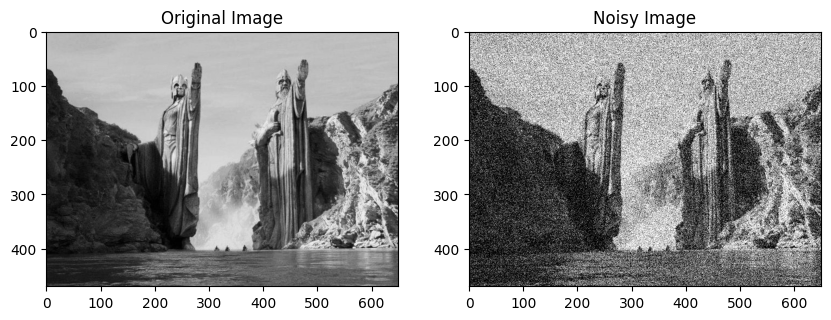

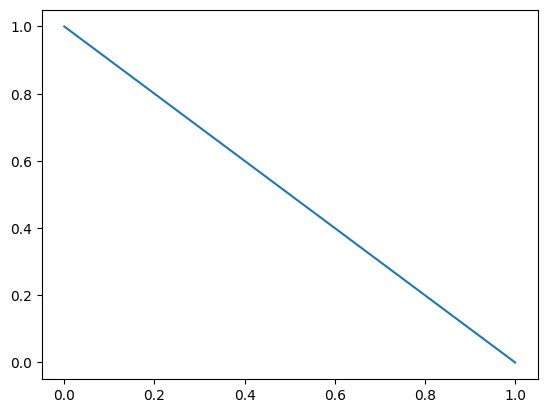

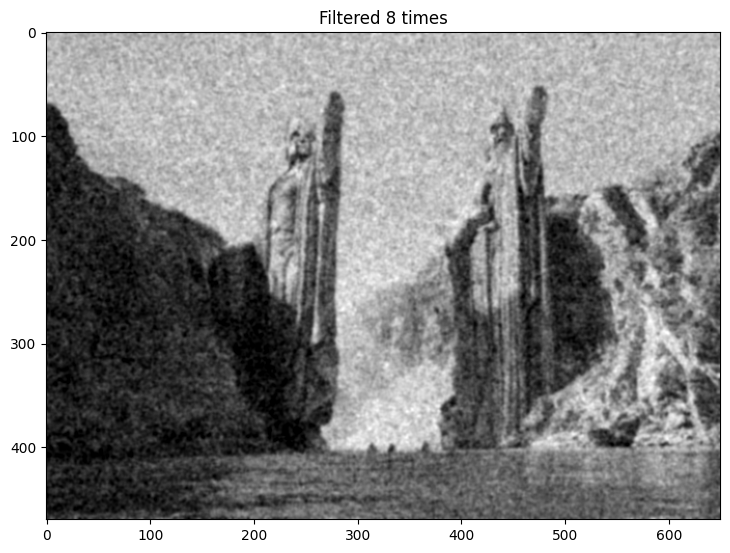

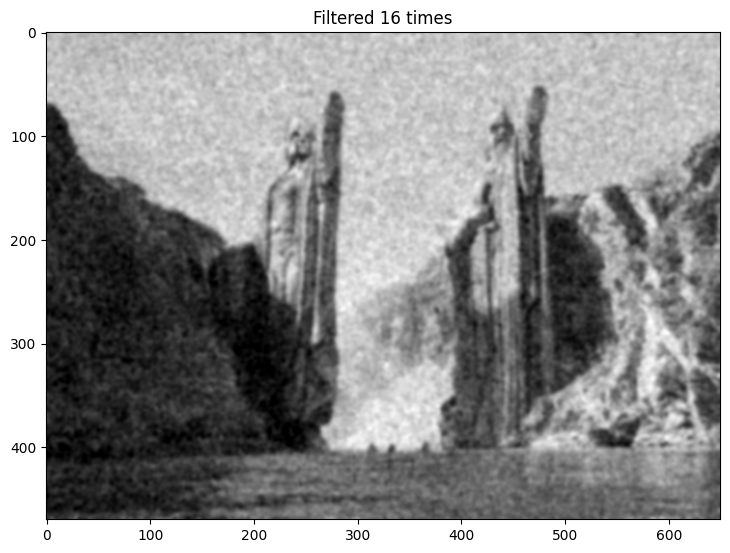

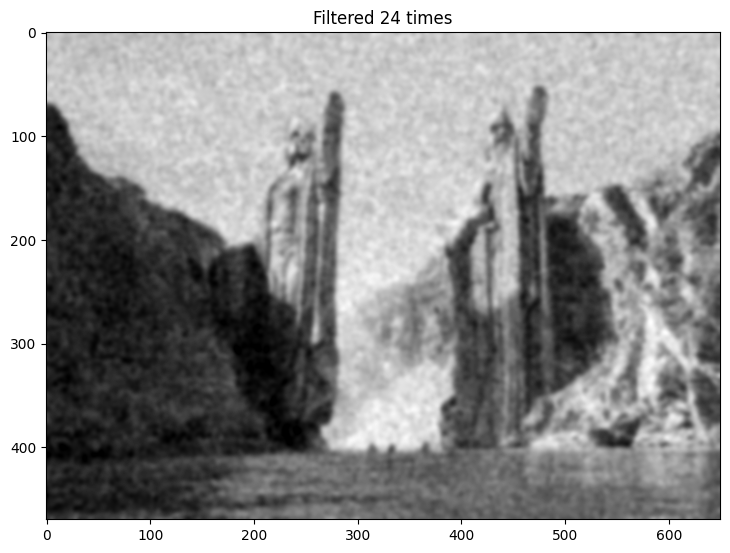

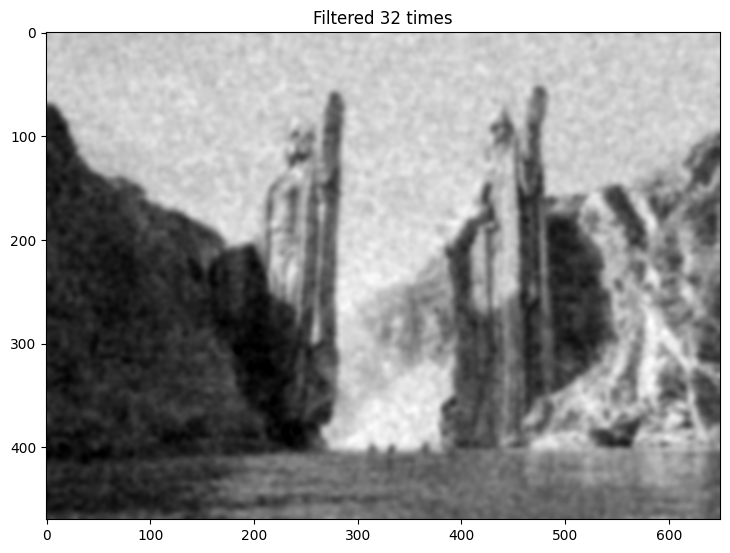

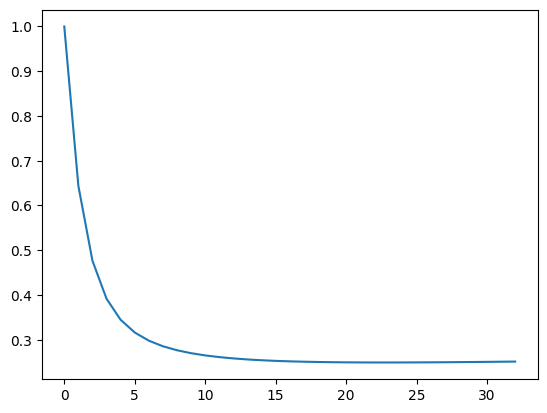

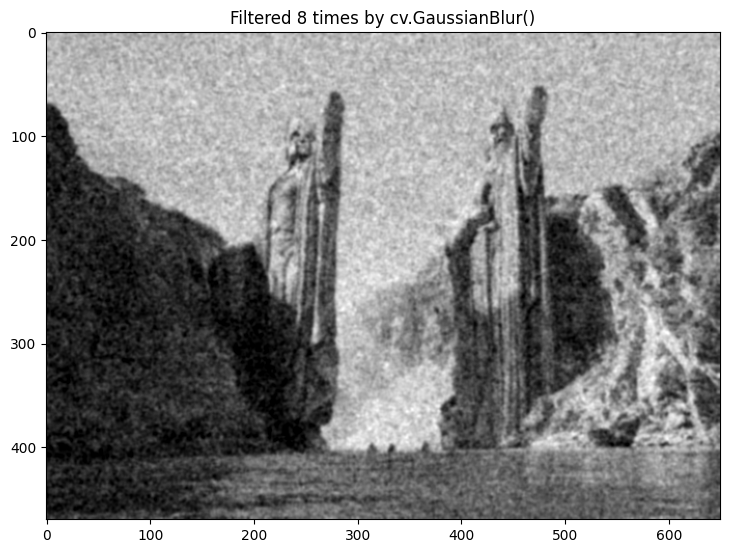

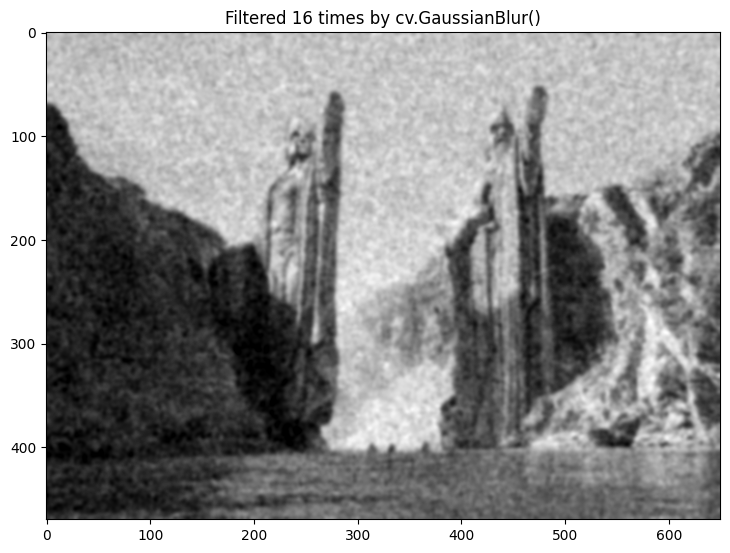

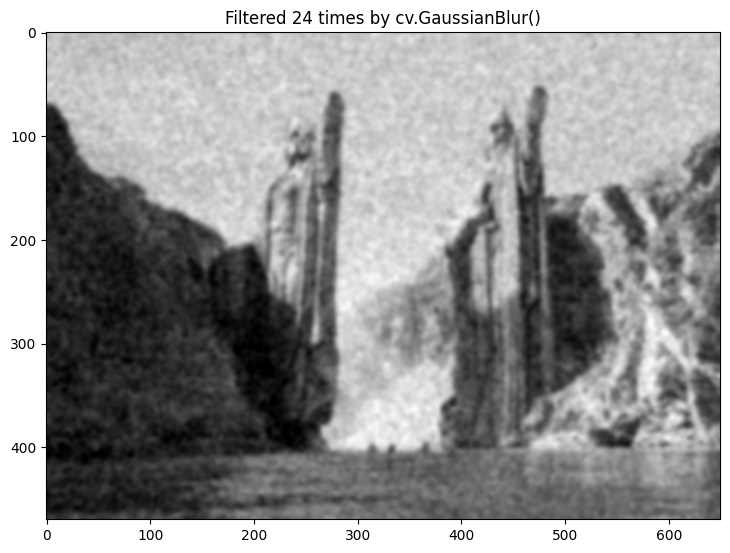

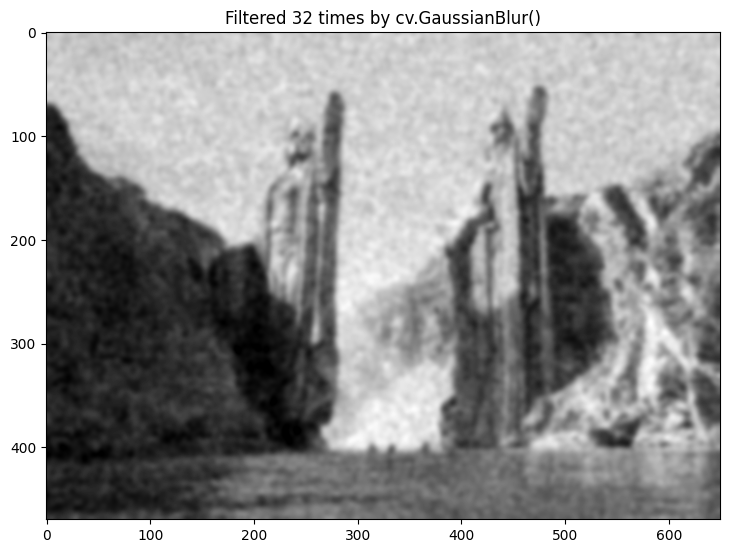

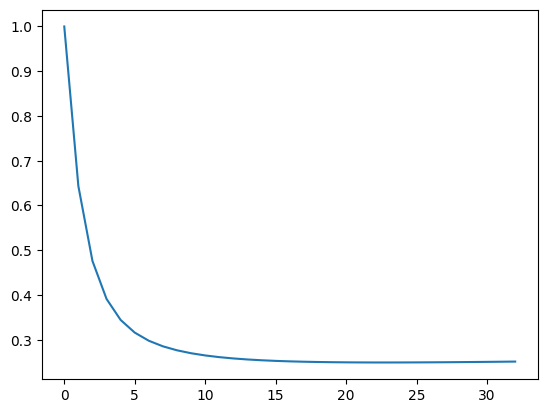

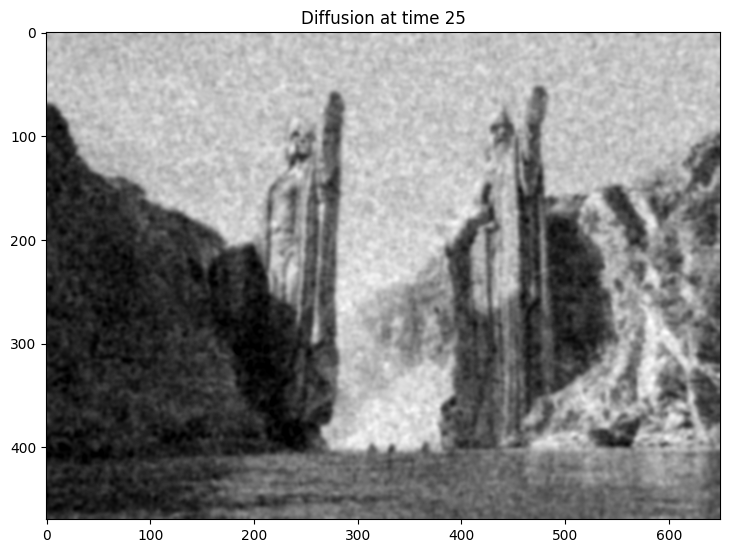

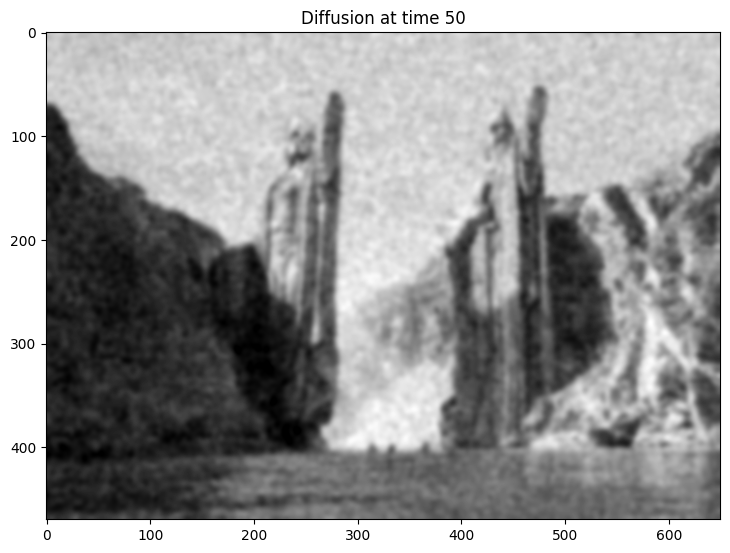

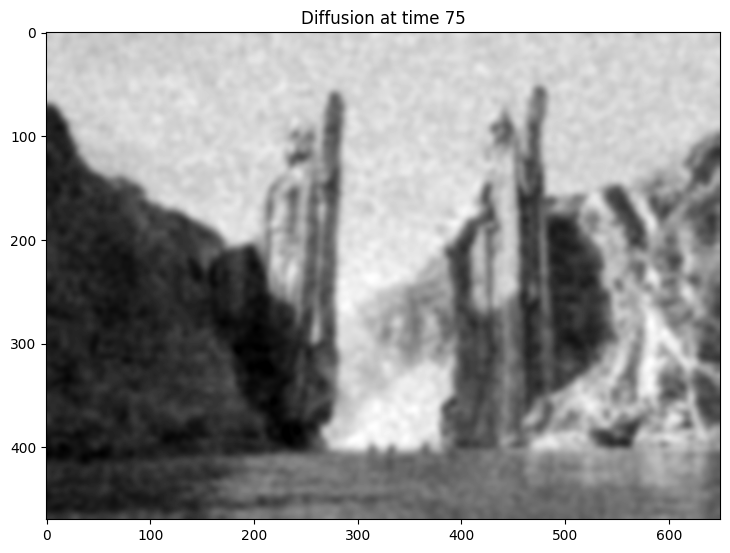

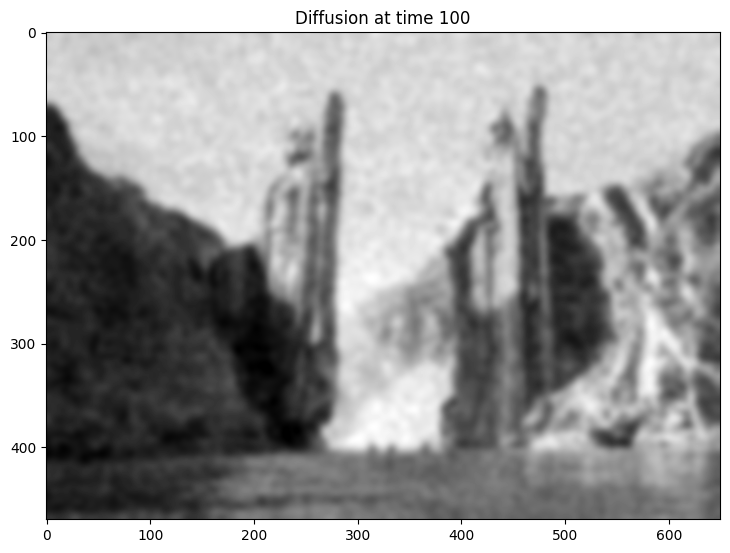

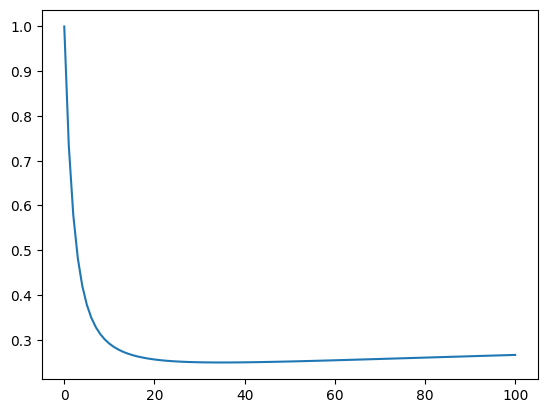

 
LSQR            Least-squares solution of  Ax = b
The matrix A has 305500 rows and 305500 columns
damp = 0.00000000000000e+00   calc_var =        0
atol = 1.00e-06                 conlim = 1.00e+08
btol = 1.00e-06               iter_lim =   611000
 
   Itn      x[0]       r1norm     r2norm   Compatible    LS      Norm A   Cond A
     0  0.00000e+00   3.257e+02  3.257e+02    1.0e+00  1.2e-02
     1  4.18410e-02   3.085e+02  3.085e+02    9.5e-01  1.9e-01   1.2e+01  1.0e+00
     2  6.15807e-02   3.002e+02  3.002e+02    9.2e-01  1.1e-01   1.7e+01  2.4e+00
     3  5.60435e-02   2.922e+02  2.922e+02    9.0e-01  1.1e-01   2.0e+01  4.5e+00
     4  7.72866e-02   2.786e+02  2.786e+02    8.6e-01  1.3e-01   2.4e+01  7.9e+00
     5  1.61429e-01   2.582e+02  2.582e+02    7.9e-01  1.4e-01   2.7e+01  1.2e+01
     6  2.59194e-01   2.314e+02  2.314e+02    7.1e-01  1.5e-01   2.9e+01  1.7e+01
     7  3.29421e-01   1.989e+02  1.989e+02    6.1e-01  1.5e-01   3.2e+01  2.3e+01
     8  3.68147e-01   1.670e+0

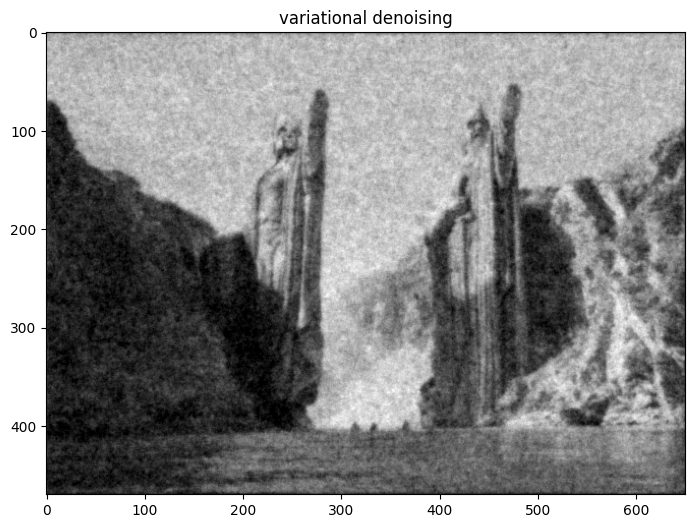

In [34]:
def main():

    I_orig_img = Image.open('/content/drive/MyDrive/data/lotr.jpg')
    I_orig_img = I_orig_img.convert('L')
    I_orig = np.array(I_orig_img)/255.0
    #print(I_orig.shape)  #(470,650)

    h, w = np.shape(I_orig)

    # Add noise
    gauss = np.random.normal(0, 0.22, (h, w))
    gauss = gauss.reshape(h, w)
    I_n = I_orig + gauss

    # Visualize
    I_orig_img.show()
    Image.fromarray((np.clip(I_n*255.0, 0, 255)).astype(np.uint8)).show()

    # Visualize original and noisy images using Matplotlib
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(I_orig, cmap='gray')
    plt.title('Original Image')

    plt.subplot(1, 2, 2)
    plt.imshow(np.clip(I_n*255.0, 0, 255), cmap='gray')
    plt.title('Noisy Image')
    plt.show()


    # Dummy error visualization
    ratios = np.linspace(0, 1, 10)
    errors = compute_errors(I_orig, [(1 - r) * I_n + r * I_orig for r in ratios])
    plt.plot(ratios, errors)
    plt.show()

    # apply gaussian filter
    show_filter(I_orig, I_n, 32)

    # apply gaussian filter using cv2.GaussianBlur() as reference
    show_filter_reference(I_orig, I_n, 32)


    # apply heat diffusion
    show_heat_diffusion(I_orig, I_n, 100)

    # apply variational approach
    show_variational(I_n)
if __name__ == "__main__":
    main()

Derivation of the energy to obtain the Euler-Lagrange equation:
From the lecture slides we know that for the functional
$E(u)=\int_{Ω}L(u,u')dx$ we have the Euler-Lagrange Equation(1D) as the necessary condition for the extrema. The Euler-Lagrange Equation states $\frac{dE}{du} = \frac{\partial L}{\partial u}-\frac{d}{dx}\frac{\partial L}{\partial u'} = 0$.

Here we have the 2D case, so I searched online for the corresponding equation for 2D. In the Generalization part, "single function of several variables with single derivative" of the website https://en.wikipedia.org/wiki/Euler%E2%80%93Lagrange_equation I found the equation.

It states that: considering a functino on n variables. If $Ω$ is some surface, then $I[f]=∫_{Ω}L(x_1,...,x_n,f,f_1,...,f_n)d\mathbf{x}; f_j = \frac{∂ f}{∂ x_j}$ is extremized only if $f$ satisfies the partial differential equation $\frac{∂ L}{∂ f}-∑_{j=1}^{n}\frac{∂}{∂ x_j}\frac{∂ L}{∂ f_j}=0$.

In our case, The $L$ function is $(I(\mathbf{x})-I_0(\mathbf{x}))^2+λ\|∇I(\mathbf{x})\|^2 $, where $\mathbf{x}$ is $(x,y)$. So we have two variables, $x$ and $y$. $f$ is $I(x,y)$. After rewriting, we can get
$$L = (I(x,y)-I_0(x,y))^2+λ\|(\frac{∂I}{∂x}(x,y),\frac{∂I}{∂y}(x,y))^T\|^2$$
$$ = (I(x,y)-I_0(x,y))^2+λ(\frac{∂I}{∂x}(x,y))^2 + λ(\frac{∂I}{∂y}(x,y))^2$$
$$ = L(x_1,x_2,f,f_1,f_2), where x_1 = x, x_2 = y, f = I(x,y), f_1 = \frac{∂I}{∂x}(x,y) and f_2 = \frac{∂I}{∂y}(x,y)$$

Now let's fill in the differential equation:
$$\frac{∂ L}{∂ f} = \frac{∂ L}{∂ I(x,y)} = 2(I(x,y)-I_0(x,y))$$
$$\frac{∂ L}{∂ f_1} = 2λ\frac{∂I}{∂x}(x,y)$$
$$\frac{∂ L}{∂ f_2} = 2λ\frac{∂I}{∂y}(x,y)$$
$$\frac{∂}{∂ x_1}\frac{∂ L}{∂ f_1} = 2λ\frac{∂}{∂ x}\frac{∂I}{∂x}(x,y) = 2λ\frac{∂ ^2I}{∂x^2}(x,y)$$
$$\frac{∂}{∂ x_2}\frac{∂ L}{∂ f_2} = 2λ\frac{∂}{∂ y}\frac{∂I}{∂y}(x,y) = 2λ\frac{∂ ^2I}{∂y^2}(x,y)$$

So the equation we get is:
$$2(I(x,y)-I_0(x,y)) - 2λ\frac{∂ ^2I}{∂x^2}(x,y) - 2λ\frac{∂ ^2I}{∂y^2}(x,y) = 0$$
Dividing both sides by 2:
$$(I(x,y)-I_0(x,y)) - λ\frac{∂ ^2I}{∂x^2}(x,y) - λ\frac{∂ ^2I}{∂y^2}(x,y) = 0$$
$$(I(x,y)-I_0(x,y)) - λ(\frac{∂ ^2I}{∂x^2}(x,y) + \frac{∂ ^2I}{∂y^2}(x,y)) = 0$$
where $\frac{∂ ^2I}{∂x^2}(x,y) + \frac{∂ ^2I}{∂y^2}(x,y)$ is also the same as $\mathbf{div}(∇I(x,y))$

After rearanging, we get:
$$(I(x,y)-I_0(x,y)) - λ\mathbf{div}(∇I(x,y)) = 0$$
$$I_0(x,y) = I(x,y) - λ\mathbf{div}(∇I(x,y))$$
which is the same as equation (5) in the exercise sheet:
$$I_0 = I_u - λ\mathbf{div}(∇I_u)$$

